# Cholesky vs LU — Performance Assessment

This notebook focuses on the **SPD (symmetric positive definite)** comparison from the poster *Numerical Linear Algebra and Sparse Matrices* and reproduces the core performance assessment between **Cholesky** and **LU**.

It contains two parts:
1. **Reference reconstruction** from the poster table.
2. **Fresh benchmark code** you can run on your machine to reproduce similar graphs.

> Note: measured timings depend on hardware, BLAS/LAPACK backend, Python version, and system load. So the benchmark curves should match the **pattern**, not necessarily the exact poster numbers.


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.linalg import cho_factor, cho_solve, lu_factor, lu_solve

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')


## 1) Poster reference data

These values are transcribed from the poster table titled **SPD performance - Cholesky vs. LU**.


In [53]:
poster_df = pd.DataFrame({
    'n': [50, 100, 200, 400, 800],
    'Cholesky_s': [23.9e-6, 37.0e-6, 95.2e-6, 0.352e-3, 2.00e-3],
    'LU_s': [22.3e-6, 42.3e-6, 129.4e-6, 0.523e-3, 3.19e-3],
})
poster_df['Speedup_LU_over_Cholesky'] = poster_df['LU_s'] / poster_df['Cholesky_s']
poster_df


,n,Cholesky_s,LU_s,Speedup_LU_over_Cholesky
0,50,2.39e-05,2.23e-05,0.933054
1,100,3.7e-05,4.23e-05,1.14324
2,200,9.52e-05,0.0001294,1.35924
3,400,0.000352,0.000523,1.4858
4,800,0.002,0.00319,1.595


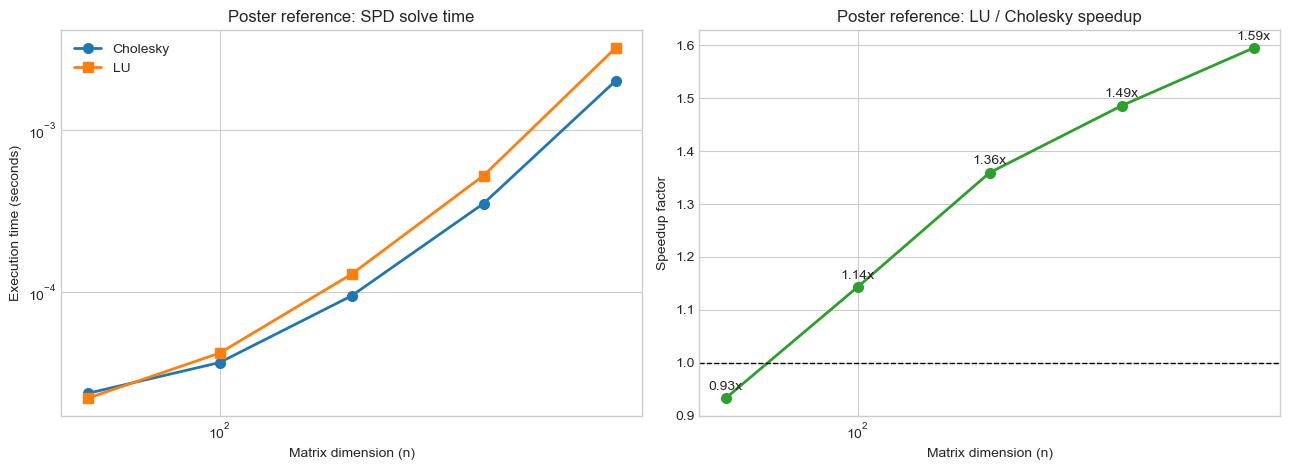

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# Timing plot
ax[0].loglog(poster_df['n'], poster_df['Cholesky_s'], 'o-', lw=2, ms=7, label='Cholesky')
ax[0].loglog(poster_df['n'], poster_df['LU_s'], 's-', lw=2, ms=7, label='LU')
ax[0].set_title('Poster reference: SPD solve time')
ax[0].set_xlabel('Matrix dimension (n)')
ax[0].set_ylabel('Execution time (seconds)')
ax[0].legend()

# Speedup plot
ax[1].semilogx(poster_df['n'], poster_df['Speedup_LU_over_Cholesky'], 'o-', lw=2, ms=7, color='tab:green')
ax[1].axhline(1.0, color='black', ls='--', lw=1)
ax[1].set_title('Poster reference: LU / Cholesky speedup')
ax[1].set_xlabel('Matrix dimension (n)')
ax[1].set_ylabel('Speedup factor')

for x, y in zip(poster_df['n'], poster_df['Speedup_LU_over_Cholesky']):
    ax[1].annotate(f'{y:.2f}x', (x, y), textcoords='offset points', xytext=(0, 6), ha='center')

plt.tight_layout()
plt.show()


In [55]:
# Estimate the scaling exponent from log-log slope: time ≈ C * n^p
def fit_power_law(x, y):
    p, log_c = np.polyfit(np.log(x), np.log(y), 1)
    return p, np.exp(log_c)

p_chol, c_chol = fit_power_law(poster_df['n'].to_numpy(), poster_df['Cholesky_s'].to_numpy())
p_lu, c_lu = fit_power_law(poster_df['n'].to_numpy(), poster_df['LU_s'].to_numpy())

print(f'Poster scaling exponent (Cholesky): {p_chol:.3f}')
print(f'Poster scaling exponent (LU):        {p_lu:.3f}')


Poster scaling exponent (Cholesky): 1.602
Poster scaling exponent (LU):        1.795


## 2) Benchmark code

The functions below generate SPD matrices and time both solvers on the same right-hand side.

**Methodological note**
- For SPD matrices, Cholesky exploits symmetry and positive definiteness.
- LU works more generally, but does more work for this matrix class.
- We time the **factorisation + solve** pathway for each method, which is the most relevant operational comparison for solving `Ax=b`.


In [56]:
def generate_spd_matrix(n, seed=None, jitter_scale=1e-2):
    """Generate a well-conditioned SPD matrix A and vector b."""
    rng = np.random.default_rng(seed)
    M = rng.standard_normal((n, n))
    A = M @ M.T + jitter_scale * n * np.eye(n)
    b = rng.standard_normal(n)
    return A, b

def solve_with_cholesky(A, b):
    c, lower = cho_factor(A, lower=True, check_finite=False)
    return cho_solve((c, lower), b, check_finite=False)

def solve_with_lu(A, b):
    lu, piv = lu_factor(A, check_finite=False)
    return lu_solve((lu, piv), b, check_finite=False)

def benchmark_solver(solver, A, b, repeats=7, warmups=2):
    for _ in range(warmups):
        solver(A, b)

    timings = []
    for _ in range(repeats):
        t0 = perf_counter()
        x = solver(A, b)
        timings.append(perf_counter() - t0)

    x_ref = np.linalg.solve(A, b)
    rel_residual = np.linalg.norm(A @ x - b) / np.linalg.norm(b)
    rel_error_vs_ref = np.linalg.norm(x - x_ref) / np.linalg.norm(x_ref)

    return {
        'mean_s': float(np.mean(timings)),
        'std_s': float(np.std(timings, ddof=1)) if len(timings) > 1 else 0.0,
        'min_s': float(np.min(timings)),
        'max_s': float(np.max(timings)),
        'rel_residual': float(rel_residual),
        'rel_error_vs_ref': float(rel_error_vs_ref),
    }

def run_spd_benchmark(dimensions=(50, 100, 200, 400, 800), repeats=7, base_seed=42):
    rows = []
    for i, n in enumerate(dimensions):
        A, b = generate_spd_matrix(n, seed=base_seed + i)

        chol_stats = benchmark_solver(solve_with_cholesky, A, b, repeats=repeats)
        lu_stats = benchmark_solver(solve_with_lu, A, b, repeats=repeats)

        rows.append({
            'n': n,
            'Method': 'Cholesky',
            **chol_stats,
        })
        rows.append({
            'n': n,
            'Method': 'LU',
            **lu_stats,
        })

    return pd.DataFrame(rows)


In [ ]:
benchmark_df = run_spd_benchmark(dimensions=(50, 100, 200, 400, 800), repeats=500)
benchmark_df


,n,Method,mean_s,std_s,min_s,max_s,rel_residual,rel_error_vs_ref
0,50,Cholesky,2.4935e-05,1.84835e-05,1.33e-05,0.0002002,5.3993e-15,4.591e-15
1,50,LU,2.9199e-05,7.98351e-06,2.19e-05,8e-05,8.49293e-15,0
2,100,Cholesky,6.3761e-05,2.96102e-05,3.56e-05,0.0002764,1.02292e-14,6.71365e-15
3,100,LU,7.6205e-05,1.86789e-05,5.94e-05,0.0001764,1.21726e-14,0
4,200,Cholesky,0.000153448,0.000104412,9.28e-05,0.0009849,6.37103e-15,5.11323e-15
5,200,LU,0.000301594,0.000211331,0.0001684,0.0011314,9.54533e-15,0
6,400,Cholesky,0.00107079,0.000489331,0.0005963,0.0032069,6.74043e-15,4.97173e-15
7,400,LU,0.00150118,0.000756359,0.0008944,0.0053473,1.14214e-14,0
8,800,Cholesky,0.00463752,0.00127888,0.0029186,0.0083193,9.99696e-15,7.56649e-15
9,800,LU,0.00701631,0.00172506,0.0043257,0.0142206,1.55495e-14,0


In [58]:
summary = (benchmark_df
           .pivot(index='n', columns='Method', values='mean_s')
           .rename_axis(columns=None)
           .reset_index())
summary['Speedup_LU_over_Cholesky'] = summary['LU'] / summary['Cholesky']
summary


,n,Cholesky,LU,Speedup_LU_over_Cholesky
0,50,2.4935e-05,2.9199e-05,1.171
1,100,6.3761e-05,7.6205e-05,1.19517
2,200,0.000153448,0.000301594,1.96545
3,400,0.00107079,0.00150118,1.40193
4,800,0.00463752,0.00701631,1.51294


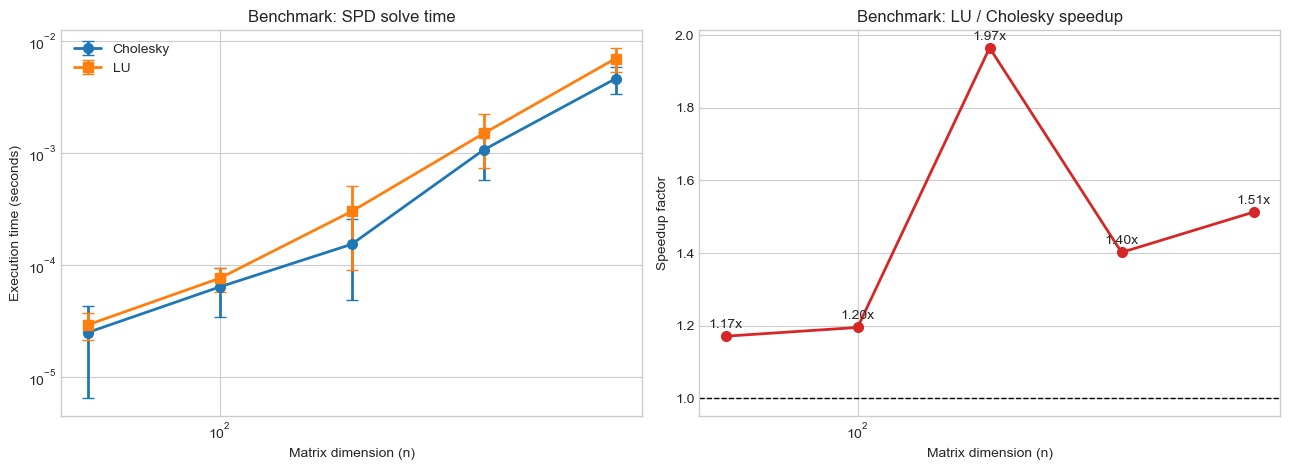

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# Benchmark timing plot with error bars
for method, marker in [('Cholesky', 'o'), ('LU', 's')]:
    sub = benchmark_df[benchmark_df['Method'] == method].sort_values('n')
    ax[0].errorbar(
        sub['n'], sub['mean_s'], yerr=sub['std_s'],
        fmt=f'{marker}-', capsize=4, lw=2, ms=7, label=method
    )

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title('Benchmark: SPD solve time')
ax[0].set_xlabel('Matrix dimension (n)')
ax[0].set_ylabel('Execution time (seconds)')
ax[0].legend()

# Benchmark speedup plot
ax[1].semilogx(summary['n'], summary['Speedup_LU_over_Cholesky'], 'o-', lw=2, ms=7, color='tab:red')
ax[1].axhline(1.0, color='black', ls='--', lw=1)
ax[1].set_title('Benchmark: LU / Cholesky speedup')
ax[1].set_xlabel('Matrix dimension (n)')
ax[1].set_ylabel('Speedup factor')

for x, y in zip(summary['n'], summary['Speedup_LU_over_Cholesky']):
    ax[1].annotate(f'{y:.2f}x', (x, y), textcoords='offset points', xytext=(0, 6), ha='center')

plt.tight_layout()
plt.show()


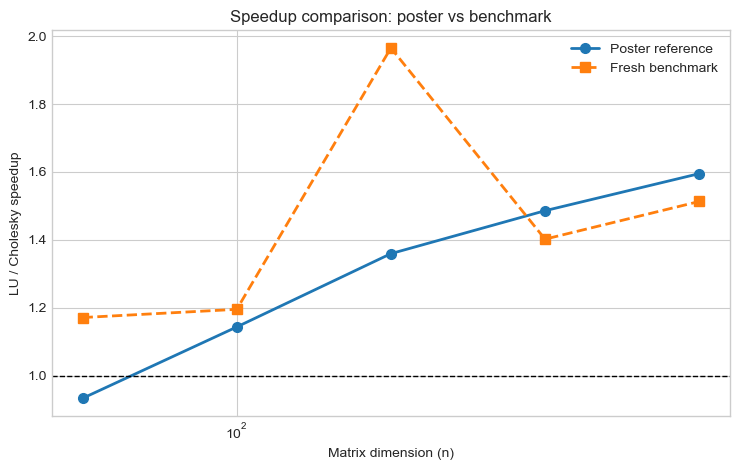

In [60]:
# Compare benchmark speedup with poster speedup on one chart
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.semilogx(poster_df['n'], poster_df['Speedup_LU_over_Cholesky'], 'o-', lw=2, ms=7, label='Poster reference')
ax.semilogx(summary['n'], summary['Speedup_LU_over_Cholesky'], 's--', lw=2, ms=7, label='Fresh benchmark')
ax.axhline(1.0, color='black', ls='--', lw=1)
ax.set_title('Speedup comparison: poster vs benchmark')
ax.set_xlabel('Matrix dimension (n)')
ax.set_ylabel('LU / Cholesky speedup')
ax.legend()
plt.tight_layout()
plt.show()


In [61]:
# Scaling exponents on your machine
def scaling_from_summary(df, method):
    sub = df[df['Method'] == method].sort_values('n')
    p, c = fit_power_law(sub['n'].to_numpy(), sub['mean_s'].to_numpy())
    return p, c

p_chol_bm, _ = scaling_from_summary(benchmark_df, 'Cholesky')
p_lu_bm, _ = scaling_from_summary(benchmark_df, 'LU')

print(f'Benchmark scaling exponent (Cholesky): {p_chol_bm:.3f}')
print(f'Benchmark scaling exponent (LU):        {p_lu_bm:.3f}')


Benchmark scaling exponent (Cholesky): 1.915
Benchmark scaling exponent (LU):        2.012


## 3) Interpretation

Typical outcome for SPD systems:
- At very small `n`, LU and Cholesky can be close because fixed overhead dominates.
- As `n` grows, **Cholesky usually pulls ahead** because it uses the SPD structure.
- The poster reports Cholesky becoming increasingly faster than LU as dimension increases, which is exactly the theoretical expectation.

If you want to extend this notebook, the next natural additions are:
- QR vs LU vs Cholesky on the same benchmark.
- Dense vs sparse matrix experiments.
- Save plots to disk for report/poster inclusion.
